## HateXplain - 2 OBJECTIVES

### Multi Task Learning

* **Dataset:** HateXplain
* **Task :** Classification

* **Target 1:** Hate speech against Women
* **Target 2:** Hate speech against Men

In [1]:
%load_ext autoreload 
%autoreload 2

In [2]:
import torch
import numpy as np
from datasets import load_dataset

/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from machinemoo import moo
from machinemoo import get_objectives, get_models
from machinemoo.analysis.visualization import plot_pareto, plot_multiple_hypervolumes #, plot_pareto_plotly
from machinemoo.analysis.metrics import compute_hypervolume_progress

import preprocessing as pp
from scalarization import NLPScalarization

In [4]:
# Setting a seed for reproducibility
from machinemoo.utils.seed_config import set_np_torch_seed
set_np_torch_seed(42)

In [5]:
import pickle

In [6]:
PREFIX_SAVE_IMAGE = 'images/2_objs'

In [7]:
PREFIX_SAVE_RESULT = '2_objs'

## Dataset and Model

In [8]:
# Get HateXplain Dataset
dataset = load_dataset("Hate-speech-CNERG/hatexplain", trust_remote_code=True)

# Choose BERT model
# model_name = "tum-nlp/bert-hateXplain"
#"hate-bert, uncased bert"
model_name="bert-base-uncased"

In [9]:
# Use GPU if its available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda:0


In [10]:
task_config = {
   "Men": {"type": "group_hate", "group": "Men"},
   "Women": {"type": "group_hate", "group": "Women"},
}

train_dataloader = pp.get_dataloader(dataset['train'], task_config)

### Dataset Analysis

African: 2873 / 3400 (18.68%) hate speech
Caucasian: 828 / 1280 (5.38%) hate speech
Asian: 397 / 540 (2.58%) hate speech
Arabs: 0 / 0 (0.00%) hate speech
Hispanic: 456 / 529 (2.96%) hate speech
Buddhism: 7 / 8 (0.05%) hate speech
Christian: 113 / 161 (0.73%) hate speech
Hindu: 37 / 52 (0.24%) hate speech
Islam: 1940 / 2415 (12.61%) hate speech
Jewish: 1719 / 1924 (11.17%) hate speech
Men: 815 / 1230 (5.30%) hate speech
Women: 2180 / 2986 (14.17%) hate speech
Heterosexual: 94 / 110 (0.61%) hate speech
Homosexual: 1466 / 1972 (9.53%) hate speech
Indigenous: 53 / 58 (0.34%) hate speech
Refugee: 801 / 1229 (5.21%) hate speech
Immigrant: 0 / 0 (0.00%) hate speech
None: 2445 / 8140 (15.89%) hate speech
Others: 0 / 0 (0.00%) hate speech


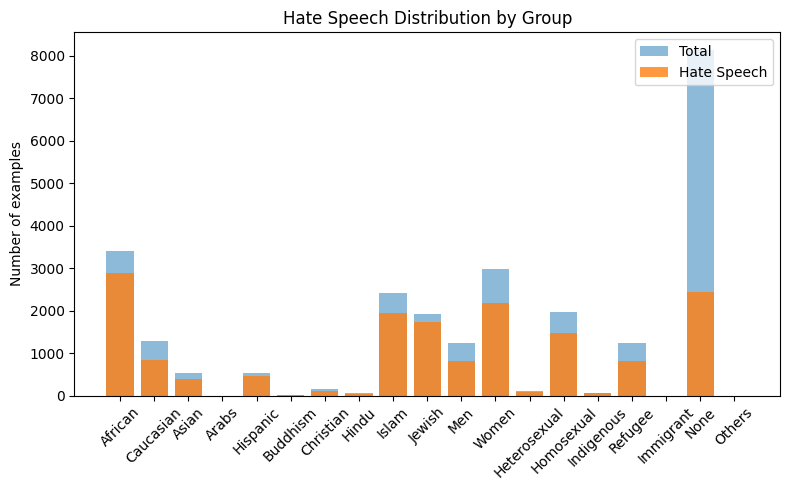

In [ ]:
import matplotlib.pyplot as plt

def analyze_group_hate_distribution(dataset_split, groups, len_dataset):
    """
    Analyzes the distribution of examples and hate speech per target group.
    
    Args:
        dataset_split: dataset['train'], dataset['test'], etc.
        groups: list of strings with target group names
        len_dataset: total number of examples in the dataset split
    Returns:
        dict: a dictionary with counts and percentages of hate speech per group
    """
    results = {}

    for group in groups:
        label_func = pp.make_group_hate_label_func(group)
        total_count = 0
        hate_count = 0

        for example in dataset_split:
            # Count total examples mentioning the group
            for group_list in example["annotators"]["target"]:
                if group in group_list:
                    total_count += 1
                    break  # avoid counting the same example multiple times
            
            # Count hate speech directed at the group
            if label_func(example) == 1:
                hate_count += 1

        results[group] = {
            "total": total_count,
            "hate": hate_count,
            "percent_hate": (hate_count / len_dataset * 100) if len_dataset > 0 else 0
        }

    return results


def plot_group_analysis(results, title="Hate Speech Distribution by Group"):
    """
    Plots the distribution of total examples and hate speech per group.

    Args:
        results: dictionary returned by analyze_group_hate_distribution
        title: plot title
    """
    groups = list(results.keys())
    total_counts = [results[g]["total"] for g in groups]
    hate_counts = [results[g]["hate"] for g in groups]
    percent_hate = [results[g]["percent_hate"] for g in groups]

    x = range(len(groups))

    fig, ax1 = plt.subplots(figsize=(8, 5))

    # Absolute counts bars
    ax1.bar(x, total_counts, label="Total", alpha=0.5)
    ax1.bar(x, hate_counts, label="Hate Speech", alpha=0.8)
    ax1.set_ylabel("Number of examples")
    ax1.set_xticks(x)
    ax1.set_xticklabels(groups, rotation=45)
    ax1.legend(loc="upper right")

    plt.title(title)
    #plt.grid()
    plt.tight_layout()
    plt.savefig(f"images/hatexplain_analysis.pdf", bbox_inches="tight")
    plt.show()

# All target groups on HateXplain dataset
groups_of_interest = [
    "African", "Caucasian", "Asian", "Arabs", "Hispanic",
    "Buddhism", "Christian", "Hindu", "Islam", "Jewish",
    "Men", "Women",
    "Heterosexual", "Homosexual",
    "Indigenous", "Refugee", "Immigrant", "None", "Others",
]

results = analyze_group_hate_distribution(dataset["train"], groups_of_interest, len(dataset["train"]))

for group, stats in results.items():
    print(f"{group}: {stats['hate']} / {stats['total']} ({stats['percent_hate']:.2f}%) hate speech")

plot_group_analysis(results)


## MOO Modeling and Training

* MOO methods:
    * MOLA
    * Random Weights

In [12]:
# Setting optimization parameter to use in all methods in this experiment
opt_params = {
    'node_time_limit': 2,
    'target_size': 500,
    'target_gap': 0,
    'node_gap': 0.05,
    'norm': False
}
results = {}
objectives_names = list(task_config.keys())

# Control optimization output (Default is False):
#   verbose=True -> show optimization progress
#   debug=True   -> show detailed debug information
verbose = False
debug = False

def machine_optimize(method, lb_estimate=0.01):
    w_scalar = NLPScalarization(
        train_dataloader = train_dataloader, 
        device = device, 
        task_names = objectives_names, 
        lower_bound_estimate=lb_estimate
    )
    moopt = moo(w_scalar, verbose=verbose, debug=debug).mo_optimization(method, **opt_params)
    objs = get_objectives(moopt)
    if method == 'mola':
        hypervolume_values = moopt.get_hypervolumes()
    else:
        hypervolume_values = compute_hypervolume_progress(objs)
    if lb_estimate == 'lipschitz':
        method = f'{method}_grad'
    results[method] = {
                    "moopt": moopt,
                    "objectives": objs,
                    "models": get_models(moopt),
                    "hypervolume": hypervolume_values
                }
    

In [13]:
    
def plot_frontier(method, color="#d73027"):
    title="Loss Trade-offs in Multi-Group Hate Speech Detection"
    plot_pareto(methods={method: results[method]['objectives']},
                labels=objectives_names, 
                title=title,
                color=color,
                fontsize=25,
                figsize=(10,7),
                save_path=f'{PREFIX_SAVE_IMAGE}_{method}.pdf'
                )

### MOLA

In [14]:
method = 'mola'
machine_optimize(method=method)

<Figure size 1000x700 with 0 Axes>

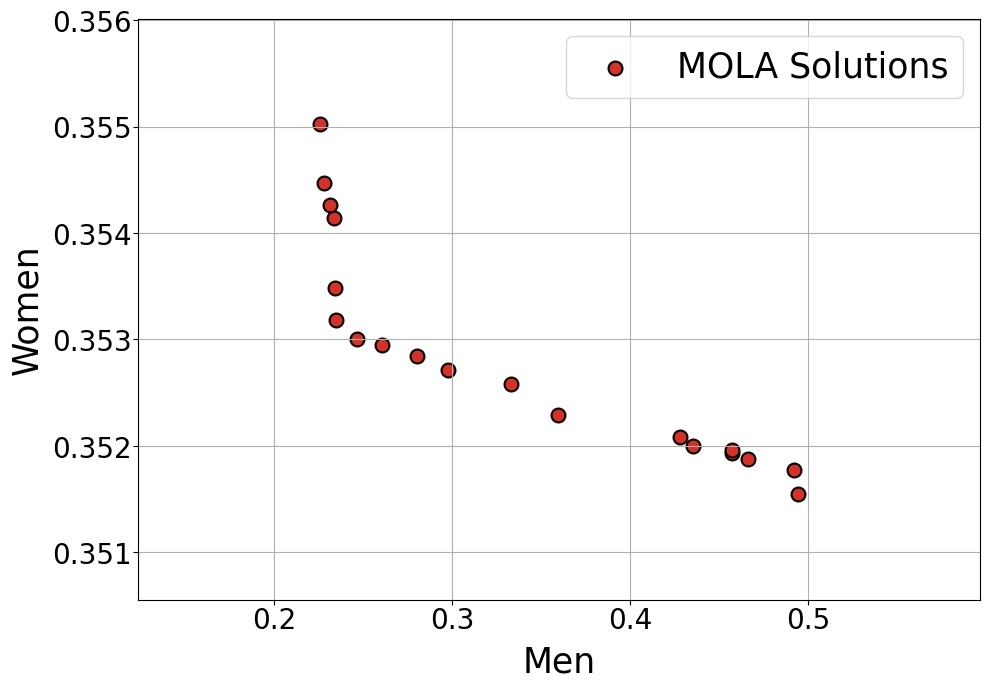

In [15]:
plot_frontier(method, color='#d73027')

In [17]:
import dill

In [18]:
# save results
with open(f"results_{PREFIX_SAVE_RESULT}.pkl", "wb") as f:
    dill.dump(results, f)

### MOLA with gradient

In [19]:
method = 'mola'
machine_optimize(method=method, lb_estimate='lipschitz') 

<Figure size 1000x700 with 0 Axes>

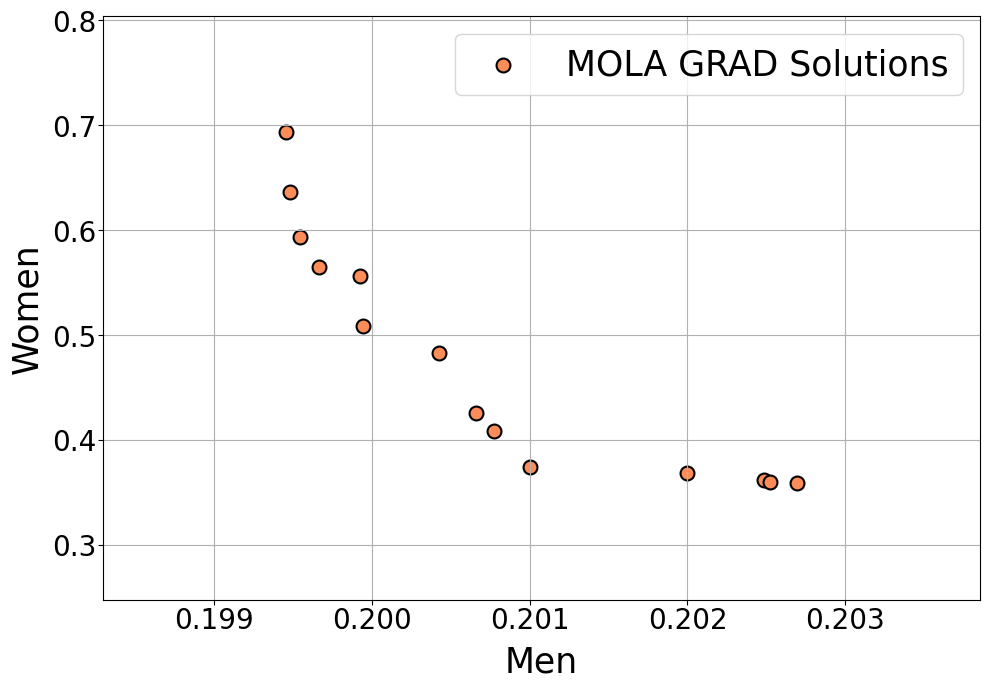

In [ ]:
plot_frontier(f'{method}_grad', color='#fc8d59')

In [20]:
# save results
with open(f"results_{PREFIX_SAVE_RESULT}.pkl", "wb") as f:
    dill.dump(results, f)

### Random Weight

In [21]:
method = 'random_weight'
machine_optimize(method=method)

### Non-dominated Solutions Analysis

In [22]:
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting
rw_solutions = results['random_weight']['objectives']
nd_indices = NonDominatedSorting().do(rw_solutions, only_non_dominated_front=True)
rw_non_dominated_solutions = rw_solutions[nd_indices]

print(f'Number of non-dominated solutions with MOLA          : {len(results['mola']['objectives'])}')
print(f'Number of non-dominated solutions with MOLA GRAD     : {len(results['mola_grad']['objectives'])}')
print(f'Number of non-dominated solutions with RANDOM WEIGHT : {len(rw_non_dominated_solutions)}')

Number of non-dominated solutions with MOLA          : 19
Number of non-dominated solutions with MOLA GRAD     : 14
Number of non-dominated solutions with RANDOM WEIGHT : 18


## A posteriori Decision Making

* Comparison between MOO methods
* Ensemble and Evaluation

<Figure size 3000x700 with 0 Axes>

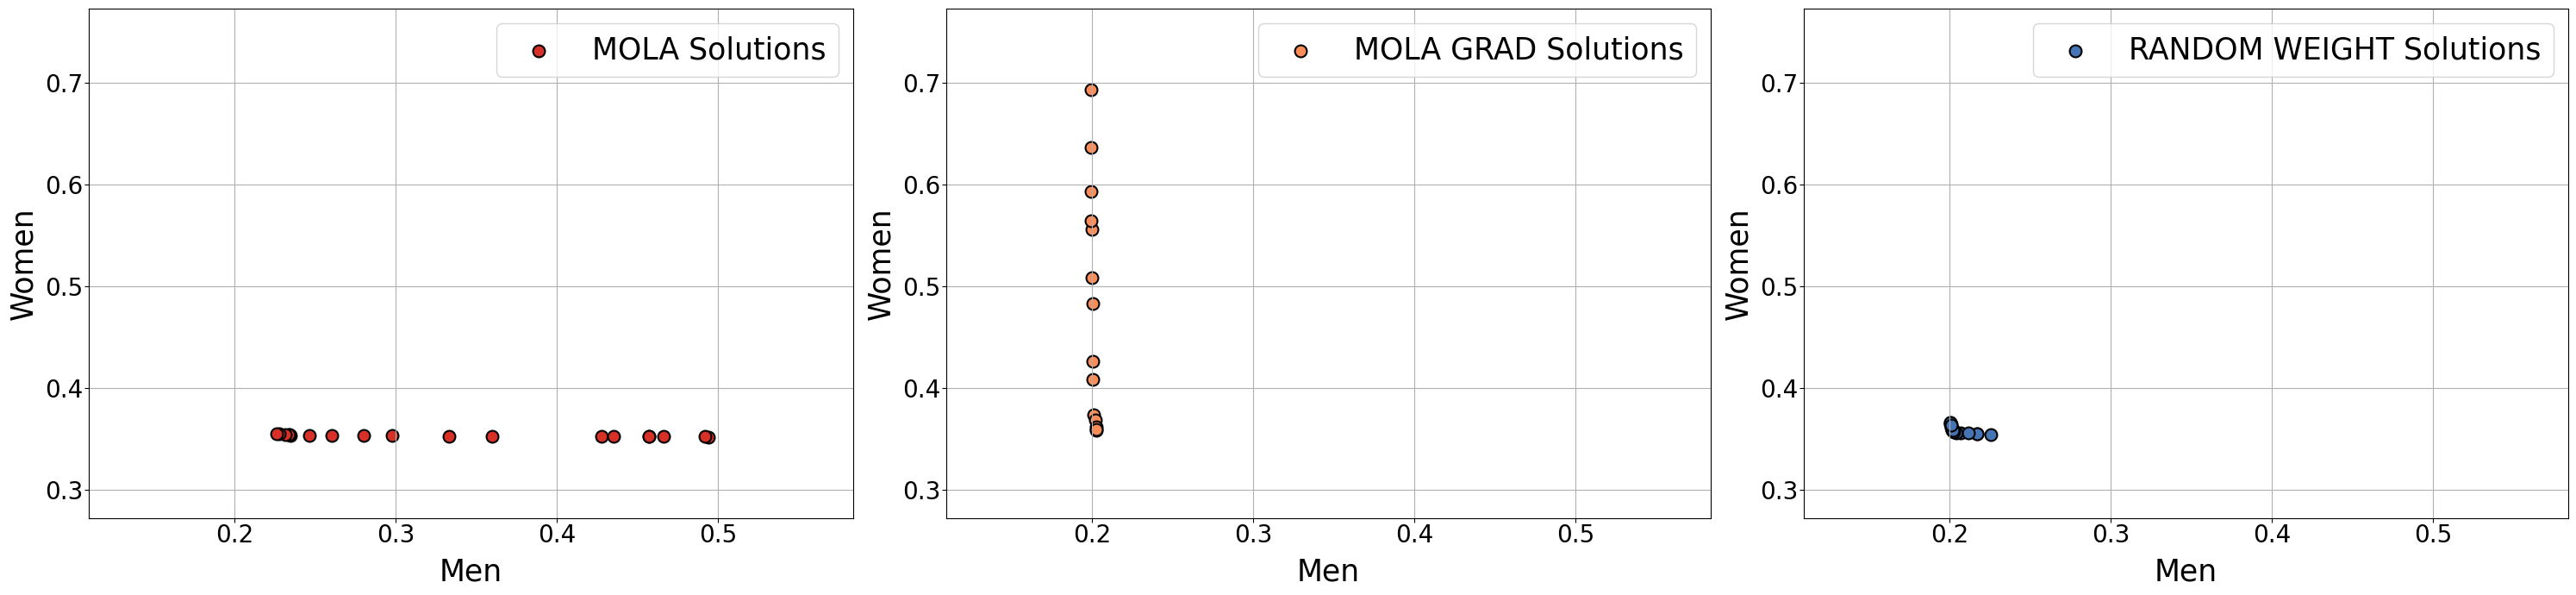

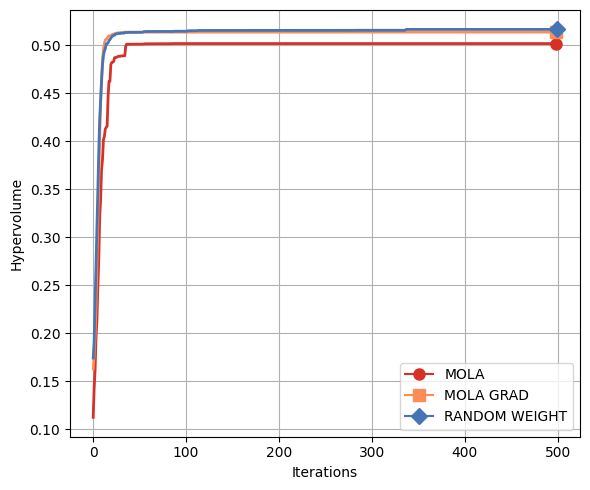

<Figure size 640x480 with 0 Axes>

In [23]:
pareto_dict = {
        method: res['objectives']
        for method, res in results.items()
        if 'objectives' in res
    }

pareto_dict['random_weight'] = rw_non_dominated_solutions

hypervolumes_dict = {
        method: res['hypervolume']
        for method, res in results.items()
        if 'hypervolume' in res
    }

plot_pareto(methods=pareto_dict,
            labels=objectives_names, 
            #title='Comparative Pareto Frontiers Across MOO Methods',
            #subset=equal.objs,
            fontsize=25,
            figsize=(10,7),
            save_path=f'{PREFIX_SAVE_IMAGE}_methods.pdf'
            )

plot_multiple_hypervolumes(methods_hv=hypervolumes_dict, save_path=f'{PREFIX_SAVE_IMAGE}_hypervolume.pdf')

In [24]:
# save results
with open(f"results_{PREFIX_SAVE_RESULT}.pkl", "wb") as f:
    dill.dump(results, f)

# get saved results
#with open(f"results_{PREFIX_SAVE_RESULT}.pkl", "rb") as f:
#    outro_dict = pickle.load(f)

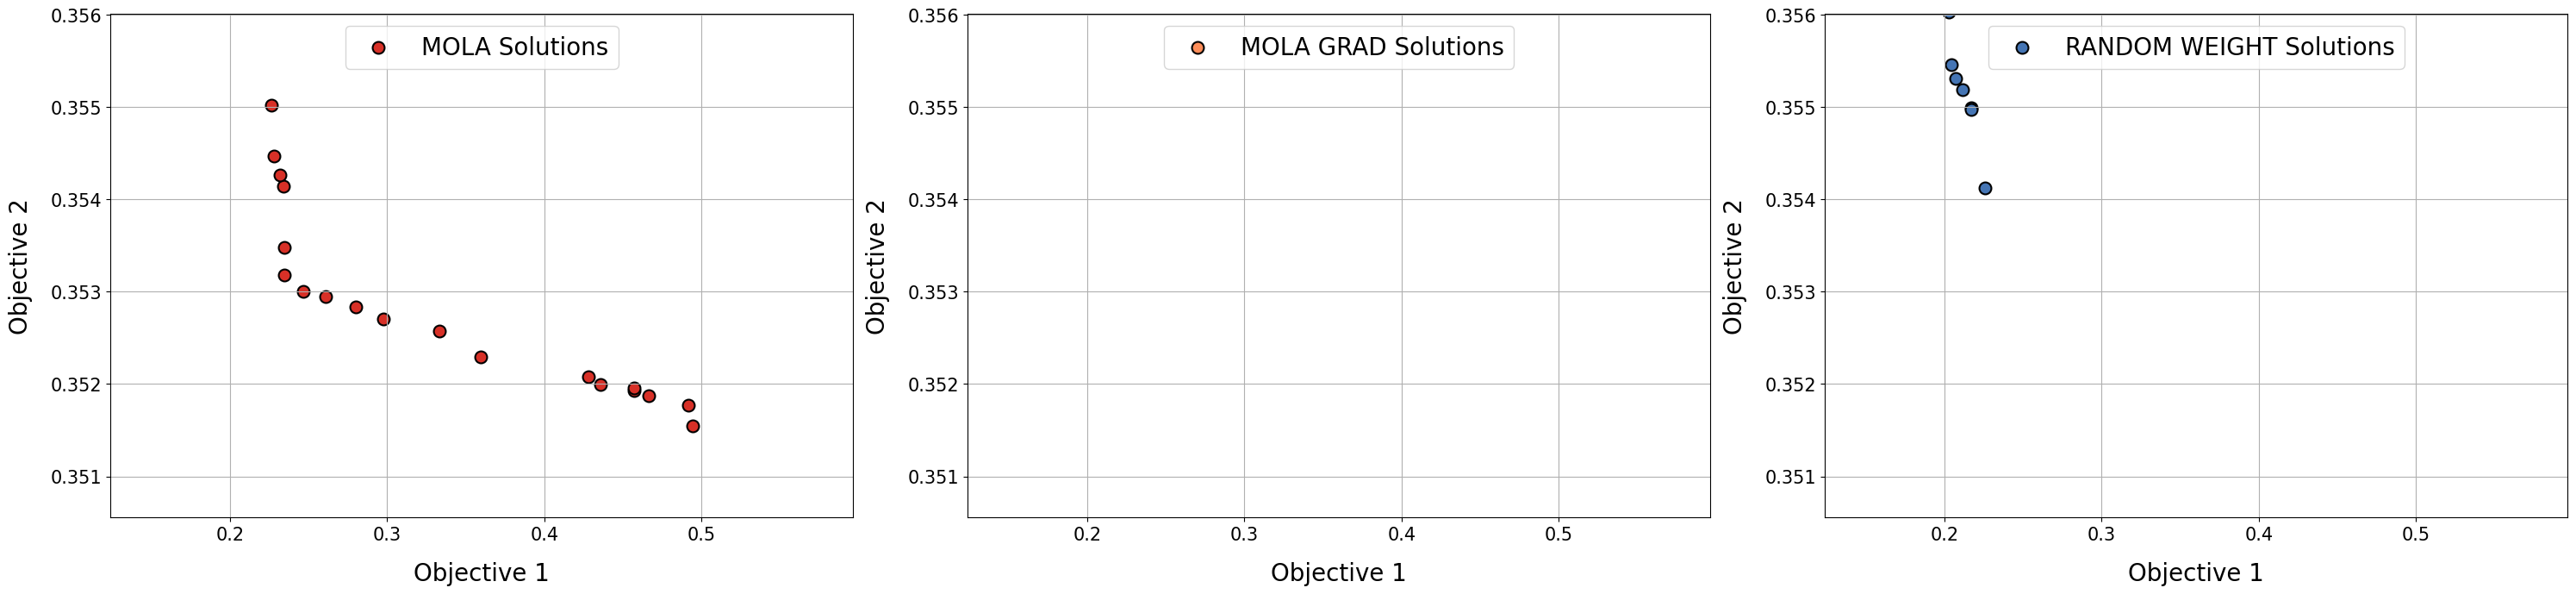

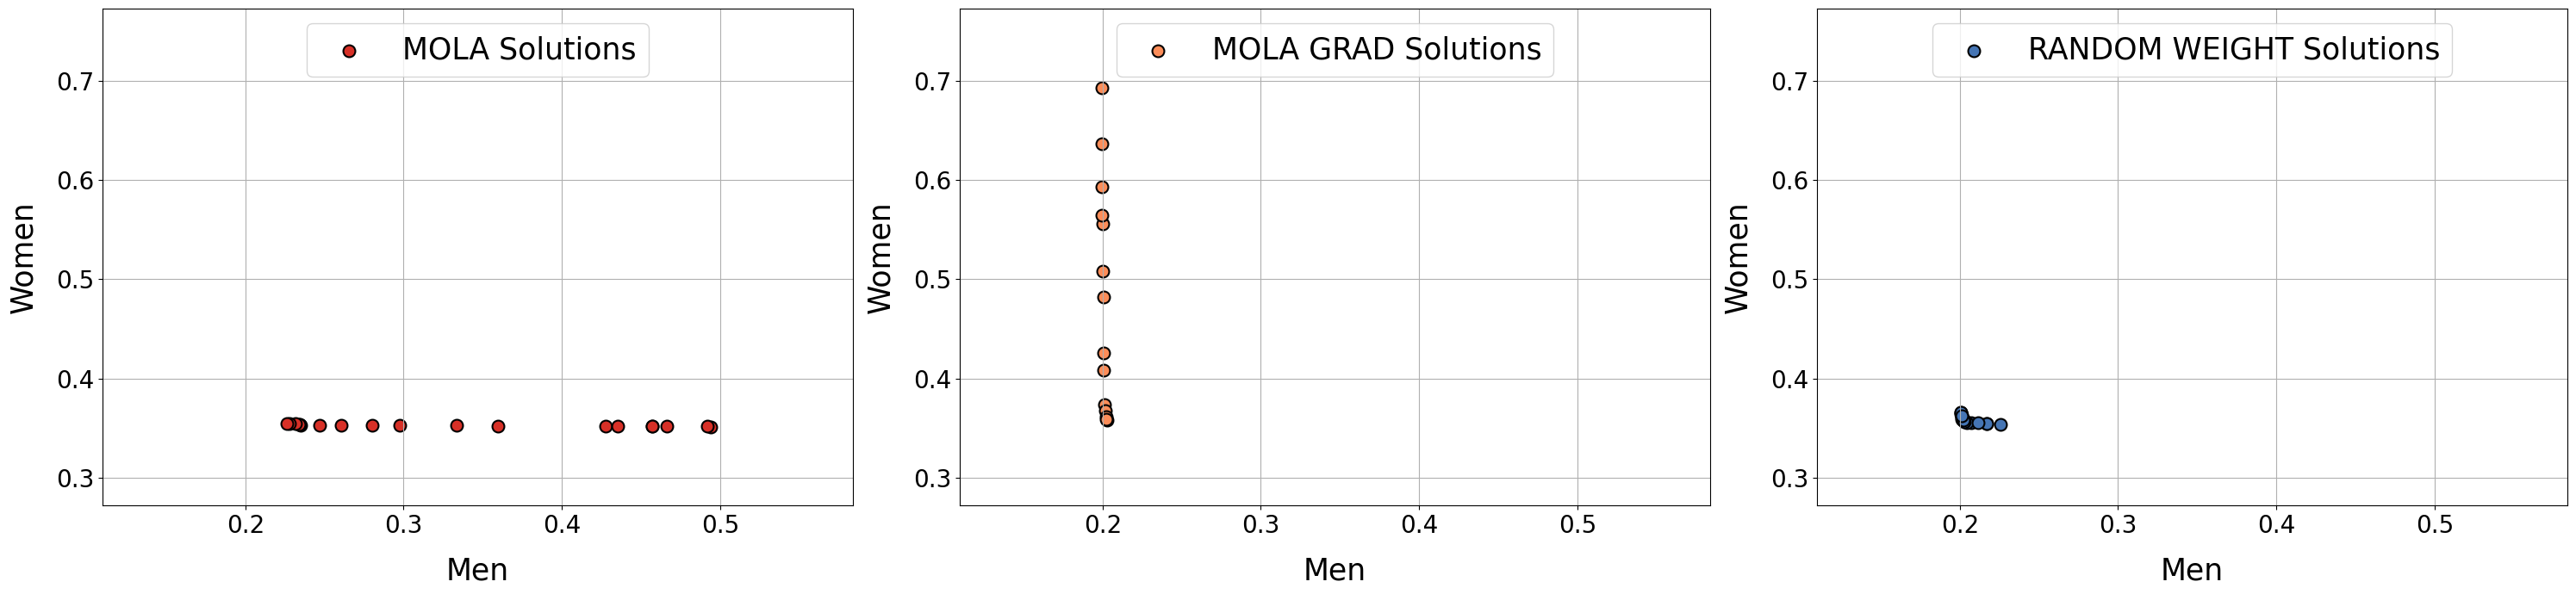

In [33]:
from machinemoo.analysis.visualization import plot_pareto_set_limit
plot_pareto_set_limit(methods=pareto_dict, axis_mode="first")
plot_pareto_set_limit(methods=pareto_dict, 
                      axis_mode="global", 
                      title="",
                      labels=objectives_names, 
                      fontsize=25,
                      figsize=(10,7),
                      save_path=f'{PREFIX_SAVE_IMAGE}_limit.pdf')

<Figure size 1000x700 with 0 Axes>

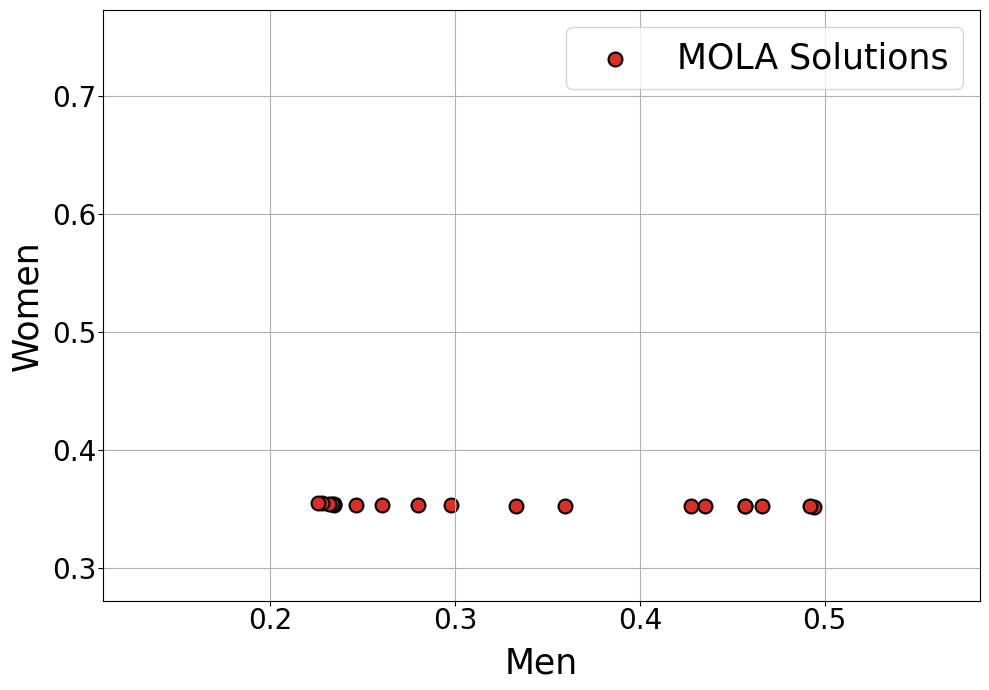

<Figure size 1000x700 with 0 Axes>

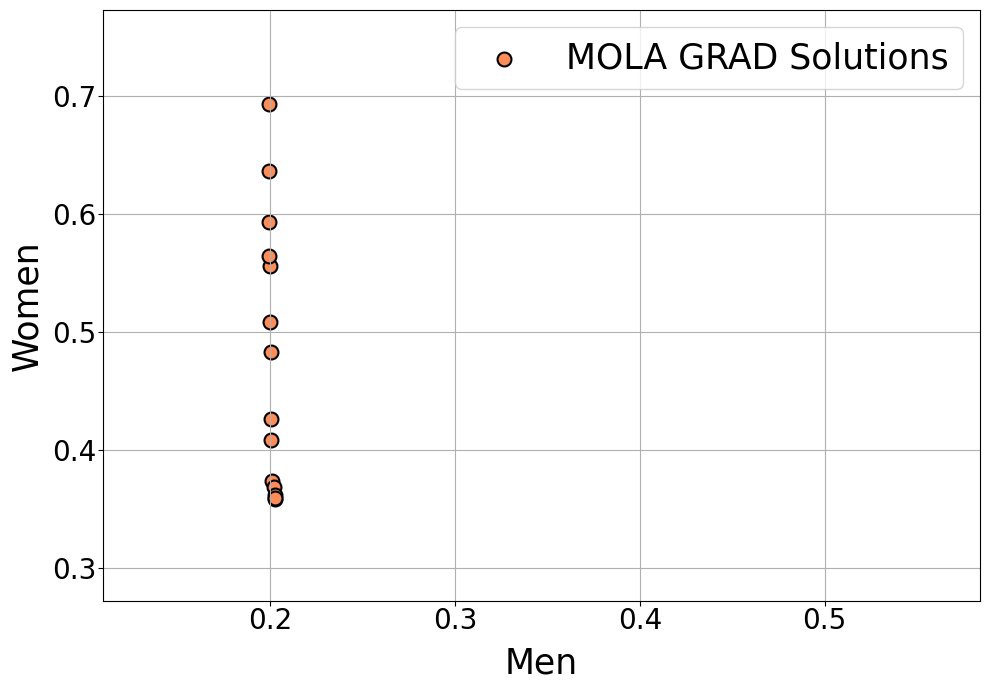

<Figure size 1000x700 with 0 Axes>

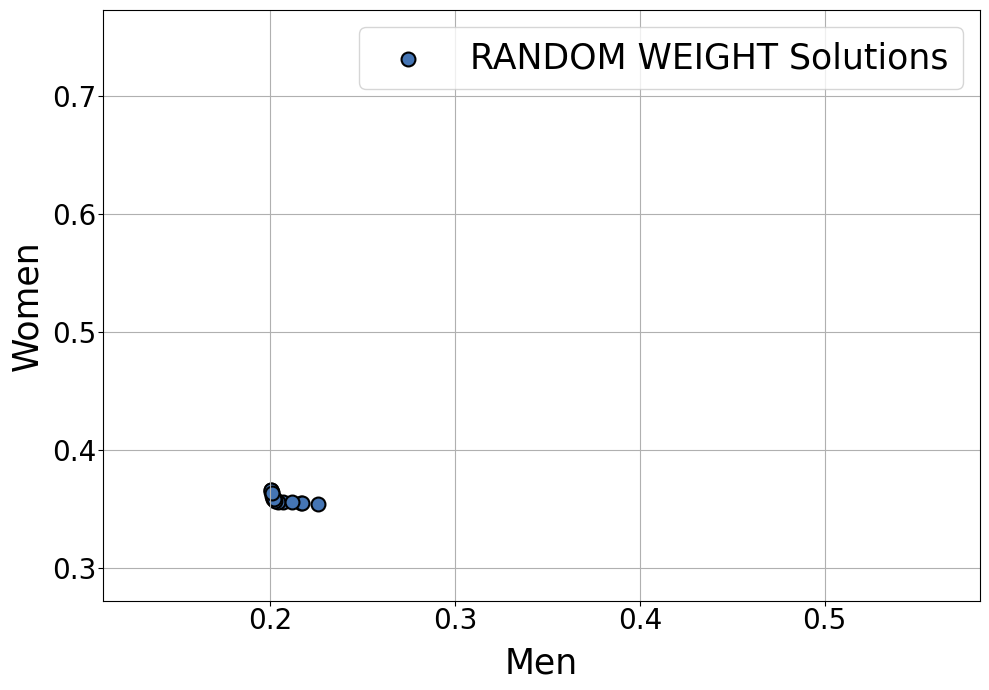

In [26]:
all_data = np.concatenate(list(pareto_dict.values()), axis=0)
limits = []
color: list[str] | str = ['#d73027', '#fc8d59', '#4575b4']

for i in range(all_data.shape[1]):
    limits.append(
        (
            all_data[:, i].min() - all_data[:, i].std(),
            all_data[:, i].max() + all_data[:, i].std(),
        )
    )

for i, (method, objs) in enumerate(pareto_dict.items()):
    plot_pareto(methods={method: objs},
                color = color[i],
                labels=objectives_names, 
                #title=title,
                fontsize=25,
                figsize=(10,7),
                save_path=f'{PREFIX_SAVE_IMAGE}_{method}_limit.pdf',
                limits=limits
    )

## EVALUATION - Best Solution Criteria with MOLA

In [ ]:
import torch
import torch.nn as nn
import numpy as np

def compute_val_losses(
    models,
    val_loader,
    task_names,
):
    """
    Calcula matriz de perdas de validação.
    
    Args:
        models: lista de modelos treinados
        val_loader: DataLoader do conjunto de validação
        objectives: lista de funções de loss (uma por objetivo)

    Returns:
        losses: tensor shape (n_models, n_objectives)
    """
    device = next(models.parameters()).device
    n_obj = len(task_names)
    #objs = torch.zeros((n_models, n_obj), dtype=torch.float32)

    val_losses = []
    for model in models:
        total_batches = 0
        eval_losses = np.zeros(n_obj)
        model.eval()
        criterion = nn.CrossEntropyLoss()
        with torch.no_grad():
            for batch in val_loader:
                embeddings = batch["embedding"].to(device)
                logits_dict = model(embeddings)
                for i, task in enumerate(task_names):
                    labels = batch[task].to(device)
                    loss = criterion(logits_dict[task], labels)
                    eval_losses[i] += loss.item()
                total_batches += 1
        # objs /= len(self.train_dataloader)
        eval_losses /= total_batches
        val_losses.append(eval_losses)

    return np.array(val_losses)

val_dataloader = pp.get_dataloader(dataset['validation'], task_config)
val_losses = compute_val_losses(results['mola']['models'], val_loader=val_dataloader, task_names=objectives_names)

In [ ]:
val_result = {}
for j, task in enumerate(objectives_names):
    best_model_idx = int(val_losses[:, j].argmin())
    best_loss = float(val_losses[:, j].min())
    val_result[task] = {
        "best_model": best_model_idx,
        "best_loss": best_loss,
    }

In [ ]:
import pandas as pd
df = pd.DataFrame(val_result).T  # .T = transpose, tasks viram índice
print(df)


In [ ]:
from machinemoo.analysis.decision import select_lowest_median_solution, select_weighted_solution

In [ ]:
# Objective weights: higher values increase priority, balance defined by the weight vector
weights_vector = [0.2, 0.4, 0.2, 0.2]
solution_weighted = select_weighted_solution(val_losses, mola['models'], weights_vector)
print(solution_weighted)

In [ ]:
# Selects the solution with the lowest median across objectives, ignoring any objectives equal to 0.0
solution_median = select_lowest_median_solution(objectives=val_losses, models=results['mola']['models'])


# Selects the solution with the lowest median across objectives, ignoring any objectives equal to 0.0 
# and values above a predefined threshold.
# Thresholds can be set per objective using a dictionary: {objective_index: max_value}.
# Here, the 1st objective has a threshold of 0.4.
solution_median_threshold = select_lowest_median_solution(
    val_losses,
    models=results['mola']['models'],
    objective_thresholds={0: 0.4}
)

In [ ]:
# Analysis three solutions together
subset = [
    solution_weighted['objectives'],
    solution_median['objectives'],
    solution_median_threshold['objectives']
]

labels = [
    f"Solution {solution_weighted['index']:<3} - Weighted",
    f"Solution {solution_median['index']:<3} - Median",
    f"Solution {solution_median_threshold['index']:<3} - Median Threshold"
]
markers = ['X', 'o', 's']

In [ ]:
plot_pareto(methods={'mola': results['mola']['objectives']},
            labels=objectives_names, 
            # title=title,
            fontsize=20,
            figsize=(10,7),
            subset=subset,
            subset_label=labels,
            save_path=f'{PREFIX_SAVE_IMAGE}_mola_decision.pdf',
            alpha=0.1,
            s_factor=5,
            subset_marker=markers,
            color='grey',
            y_threshold=0.6
            )

## EVALUATION MTL

In [27]:
import torch
import torch.nn as nn
import numpy as np
from tqdm import tqdm

class MultiTaskModel(nn.Module):
    def __init__(
        self,
        task_names: list[str],
        input_dim: int = 50,
        hidden_dim: int = 32,
        num_labels: int = 2,
        dropout_rate: float = 0.3
    ) -> None:
        super().__init__()
        self.dropout = nn.Dropout(dropout_rate)
        self.shared_fc = nn.Linear(input_dim, hidden_dim)
        self.classifiers = nn.ModuleDict(
            {task: nn.Linear(hidden_dim, num_labels) for task in task_names}
        )

    def forward(self, embeddings):
        x = self.dropout(embeddings)
        features = self.shared_fc(x)
        return {task: head(features) for task, head in self.classifiers.items()}


class MultiTaskBaseline:
    """
    Standard multi-task learning model (baseline) for comparison with MOO.
    """

    def __init__(self, train_dataloader, task_names: list[str], device: str = "cpu", epochs: int = 3):
        self.device = device
        self.task_names = task_names
        self.train_dataloader = train_dataloader
        self.epochs = epochs
        self.model = MultiTaskModel(task_names=task_names).to(device)

    def compute_total_loss(self, logits_dict: dict[str, torch.Tensor], labels_dict: dict[str, torch.Tensor]):
        criterion = nn.CrossEntropyLoss()
        total_loss = sum(criterion(logits_dict[task], labels_dict[task]) for task in self.task_names)
        return total_loss

    def train(self, lr: float = 2e-5):
        optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)
        self.model.train()

        for epoch in range(self.epochs):
            total_loss = 0
            for batch in tqdm(self.train_dataloader, desc=f"Epoch {epoch+1}/{self.epochs}", leave=False):
                embeddings = batch["embedding"].to(self.device)
                labels_dict = {task: batch[task].to(self.device) for task in self.task_names}

                logits_dict = self.model(embeddings)
                loss = self.compute_total_loss(logits_dict, labels_dict)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                total_loss += loss.item()

            print(f"Epoch {epoch+1} - Avg loss: {total_loss / len(self.train_dataloader):.4f}")

        return self.model

    def evaluate(self, dataloader):
        self.model.eval()
        criterion = nn.CrossEntropyLoss()
        total_batches = 0
        eval_losses = {task: 0.0 for task in self.task_names}

        with torch.no_grad():
            for batch in dataloader:
                embeddings = batch["embedding"].to(self.device)
                labels_dict = {task: batch[task].to(self.device) for task in self.task_names}

                logits_dict = self.model(embeddings)
                for task in self.task_names:
                    eval_losses[task] += criterion(logits_dict[task], labels_dict[task]).item()
                total_batches += 1

        avg_losses = {task: loss / total_batches for task, loss in eval_losses.items()}
        return avg_losses


In [28]:
test_dataloader = pp.get_dataloader(dataset['test'], task_config)
val_dataloader = pp.get_dataloader(dataset['validation'], task_config)

In [29]:
task_names = objectives_names
baseline = MultiTaskBaseline(train_dataloader, task_names, device="cuda")
baseline.train(lr=2e-5)

avg_losses = baseline.evaluate(test_dataloader)
print(avg_losses)


Epoch 1 - Avg loss: 1.2701


Epoch 2 - Avg loss: 1.2309


Epoch 3 - Avg loss: 1.1953
{'Men': 0.5948629206226718, 'Women': 0.5656058096116588}


####

In [30]:
def evaluate_accuracy(model, dataloader, task_names, device="cpu"):
    """
    Computes accuracy per task.

    Args:
        model: PyTorch model (multi-task)
        dataloader: DataLoader for validation/test
        task_names: list of task names
        device: "cpu" or "cuda"
    
    Returns:
        dict: {task_name: accuracy}
    """
    model.eval()
    correct_counts = {task: 0 for task in task_names}
    total_counts = {task: 0 for task in task_names}

    with torch.no_grad():
        for batch in dataloader:
            embeddings = batch["embedding"].to(device)
            labels_dict = {task: batch[task].to(device) for task in task_names}

            logits_dict = model(embeddings)
            for task in task_names:
                preds = torch.argmax(logits_dict[task], dim=1)
                correct_counts[task] += (preds == labels_dict[task]).sum().item()
                total_counts[task] += labels_dict[task].size(0)

    accuracies = {task: correct_counts[task] / total_counts[task] for task in task_names}
    return accuracies


In [31]:
baseline = MultiTaskBaseline(train_dataloader, task_names, device="cuda")
baseline_model = baseline.train(lr=2e-5)

baseline_acc = evaluate_accuracy(baseline_model, val_dataloader, task_names, device="cuda")
print("Multi-task baseline accuracy per task:")
for task, acc in baseline_acc.items():
    print(f"{task}: {acc*100:.2f}%")


Epoch 1 - Avg loss: 1.4384


Epoch 2 - Avg loss: 1.4013


Epoch 3 - Avg loss: 1.3662
Multi-task baseline accuracy per task:
Men: 59.94%
Women: 54.84%


In [32]:
moo_acc = []
moo_models = results['mola']['models']
#objs = results['mola']['objectives']
for model in results['mola']['models']:
    accs = evaluate_accuracy(model, val_dataloader, task_names, device="cuda")
    moo_acc.append(accs)
    # print("MOO model accuracy per task:")
    # for task, acc in accs.items():
    #     print(f"{task}: {acc*100:.2f}%")

import pandas as pd
df_moo = pd.DataFrame(moo_acc)
df_moo = df_moo * 100
print(df_moo.round(2))


print("\nMean accuracy per task (MOO frontier):")
print(df_moo.round(2).mean())

      Men  Women
0   94.33  85.12
1   94.33  85.12
2   94.33  85.12
3   94.33  85.12
4   94.33  85.12
5   94.33  85.12
6   94.33  85.12
7   94.33  85.12
8   94.33  85.12
9   94.33  85.12
10  94.33  85.12
11  94.33  85.12
12  94.33  85.12
13  94.33  85.12
14  94.33  85.12
15  94.33  85.12
16  94.33  85.12
17  94.33  85.12
18  94.33  85.12

Mean accuracy per task (MOO frontier):
Men      94.33
Women    85.12
dtype: float64
